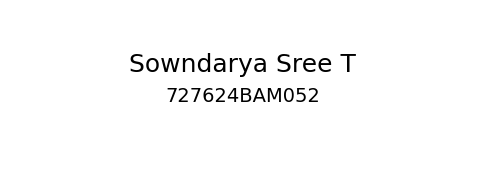

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,2))

plt.text(0.5,0.6,"Sowndarya Sree T",ha="center",fontsize=18)

plt.text(0.5,0.4,"727624BAM052",ha="center",fontsize=14)

plt.axis("off")
plt.show()

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv("/content/ev_fleet_dataset_v15.csv")

df.head()

,vehicle_id,driver_id,driver_name,manufacturer,monthly_revenue_generation,yearly_revenue,maintenance_cost,driver_revenue,battery_percentage,expected_distance_km,trip_speed_kmph,vehicle_status,date,time,violations
0,EV-103,103,Manikandan,Tesla,289059.48,3222512.77,24736.59,5565.59,13,57.71,92.60,Running,15-05-2024,11.37,NaN
1,EV-436,436,Arun,Tata,399923.92,5127508.07,17823.20,3609.57,74,374.99,64.29,Running,04-03-2024,20.34,Speeding
2,EV-861,861,Vetri,Maruti,106210.59,1153897.98,12474.27,2241.18,28,134.45,34.58,Running,08-12-2024,14.49,Harsh Braking
3,EV-271,271,Chandran,Mahindra,12673.89,138429.34,25721.08,3584.13,94,368.07,48.41,Running,07-05-2025,13.43,Route Deviation
4,EV-107,107,Suriya,BMW,154274.96,1662185.19,32126.37,2329.66,69,396.92,40.88,Running,04-10-2024,11.17,Overcharging


In [25]:
df.shape

(10000, 15)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   vehicle_id                  10000 non-null  object 
 1   driver_id                   10000 non-null  int64  
 2   driver_name                 10000 non-null  object 
 3   manufacturer                10000 non-null  object 
 4   monthly_revenue_generation  10000 non-null  float64
 5   yearly_revenue              10000 non-null  float64
 6   maintenance_cost            10000 non-null  float64
 7   driver_revenue              10000 non-null  float64
 8   battery_percentage          10000 non-null  int64  
 9   expected_distance_km        10000 non-null  float64
 10  trip_speed_kmph             10000 non-null  float64
 11  vehicle_status              10000 non-null  object 
 12  date                        10000 non-null  object 
 13  time                        1000

In [27]:
list(df)

['vehicle_id',
 'driver_id',
 'driver_name',
 'manufacturer',
 'monthly_revenue_generation',
 'yearly_revenue',
 'maintenance_cost',
 'driver_revenue',
 'battery_percentage',
 'expected_distance_km',
 'trip_speed_kmph',
 'vehicle_status',
 'date',
 'time',
 'violations']

In [28]:
df.describe()

,driver_id,monthly_revenue_generation,yearly_revenue,maintenance_cost,driver_revenue,battery_percentage,expected_distance_km,trip_speed_kmph,time
count,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,504.470600,203879.814685,2.447606e+06,25659.699905,3133.839614,52.871600,253.968345,38.590629,13.091925
std,289.724434,126574.484429,1.528926e+06,9203.534781,1192.398937,27.911923,142.698527,30.177461,5.149171
min,1.000000,0.000000,0.000000e+00,4068.890000,200.000000,5.000000,20.000000,0.000000,0.000000
25%,251.000000,103955.352500,1.249759e+06,18625.995000,2266.350000,29.000000,134.682500,0.000000,9.060000
50%,506.500000,200442.515000,2.394791e+06,25377.485000,3066.735000,53.000000,245.655000,43.765000,13.225000
75%,758.000000,280523.895000,3.378185e+06,32070.227500,3936.722500,77.250000,361.322500,61.872500,17.350000
max,1000.000000,499796.540000,6.611489e+06,50000.000000,7478.170000,100.000000,600.000000,128.180000,23.590000


In [29]:
df.isnull().sum()

,0
vehicle_id,0
driver_id,0
driver_name,0
manufacturer,0
monthly_revenue_generation,0
yearly_revenue,0
maintenance_cost,0
driver_revenue,0
battery_percentage,0
expected_distance_km,0


In [30]:
running = df[df["vehicle_status"] == "Running"]

print("Vehicles Running =", len(running))

Vehicles Running = 7033


In [31]:
Charging = df[df["vehicle_status"] == "Charging"]

print("Vehicles Charging =", len(Charging))

Vehicles Charging = 1471


In [32]:
Garage = df[df["vehicle_status"] == "Garage"]

print("Vehicles Garage =", len(Garage))

Vehicles Garage = 1017


In [33]:
Maintenance = df[df["vehicle_status"] == "Maintenance"]

print("Vehicles Maintenance =", len(Maintenance))

Vehicles Maintenance = 479


In [34]:
count = df.groupby("manufacturer")["vehicle_id"].count()

print(count)

manufacturer
BMW         2000
Mahindra    2000
Maruti      2000
Tata        2000
Tesla       2000
Name: vehicle_id, dtype: int64


In [35]:
charging = df[df["battery_percentage"] < 20]

print("Vehicles Need Charging =", len(charging))

Vehicles Need Charging = 1535


In [36]:
cost = df.groupby("manufacturer")["maintenance_cost"].sum()

print(cost)

manufacturer
BMW         51257339.64
Mahindra    51377741.09
Maruti      51879992.78
Tata        50616071.45
Tesla       51465854.09
Name: maintenance_cost, dtype: float64


In [37]:
vehicle_cost = df.groupby("vehicle_id")["maintenance_cost"].sum()

print(vehicle_cost.head(20))

vehicle_id
EV-1       372919.53
EV-10      307755.64
EV-100     153532.38
EV-1000     96868.62
EV-101     320494.67
EV-102     286791.14
EV-103     207952.54
EV-104     316862.76
EV-105     206853.65
EV-106     292169.71
EV-107     224126.59
EV-108     220068.20
EV-109     422858.09
EV-11      142080.13
EV-110     165119.82
EV-111     420369.53
EV-112     370330.82
EV-113     452321.84
EV-114     266828.28
EV-115     143429.71
Name: maintenance_cost, dtype: float64


In [38]:
driver = df.groupby("driver_name")["driver_revenue"].sum()

print("Driver Name :", driver.idxmax())
print("Revenue :", f"{driver.max():,.0f}")

Driver Name : Boopathi
Revenue : 490,930


In [39]:
loss = df.groupby("driver_name")["maintenance_cost"].sum()

print("Driver Name :", loss.idxmax())
print("Loss :", f"{loss.max():,.0f}")

Driver Name : Vaishnavi
Loss : 4,020,363


In [40]:
v = df[df["violations"] != "None"]

result = v.groupby("driver_name").size()

print("Driver Name :", result.idxmax())
print("Violations :", result.max())

Driver Name : Vaishnavi
Violations : 154


In [41]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df["month"] = df["date"].dt.month_name()

month_revenue = df.groupby("month")["monthly_revenue_generation"].sum()

for month, revenue in month_revenue.items():
    print(month, ":", f"{revenue:,.0f}")

April : 161,519,534
August : 170,310,399
December : 174,537,919
February : 155,702,195
January : 169,483,106
July : 172,550,766
June : 168,234,548
March : 172,028,334
May : 178,335,084
November : 175,894,544
October : 177,758,712
September : 162,443,005
